## 6-month PhD Research Proposal Presentation

Interbasin exchangesin stratified lakes

In [1]:
# imports
import ewgreaders as ewg
import xarray as xr
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from tqdm.notebook import tqdm

### Schematics

#### Winter convective mixing depth

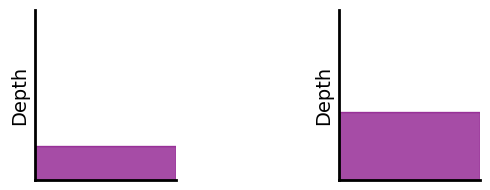

In [3]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(5, 2), sharey=True)

ax[0].axhspan(0, 0.2, color='purple', alpha=0.7)
ax[1].axhspan(0, 0.4, color='purple', alpha=0.7)


for i in range(len(ax)):
    ax[i].set_ylabel('Depth', fontsize=14)
    ax[i].set_xlim(0, 1)
    ax[i].set_ylim(0, 1)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].spines[['left', 'bottom']].set_linewidth(2)

plt.tight_layout(w_pad=10)
plt.savefig('../gallery/surf/2026_03_16/winter_mixing_depth.svg', bbox_inches='tight')
plt.show()

#### Summer stratification duration

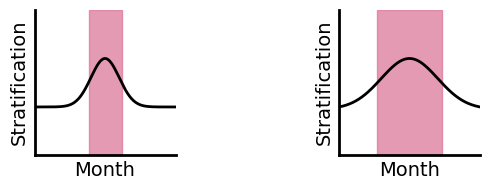

In [4]:
x = np.linspace(0, 1, 500)
summer = np.exp(-((x - 0.5)**2) / (2 * 0.1**2))
extended = np.exp(-((x - 0.5)**2) / (2 * 0.2**2))
# normalize
summer = (summer - summer.min()) / (summer.max() - summer.min())
extended = (extended - extended.min()) / (extended.max() - extended.min())
idx_summer = np.where(summer > 0.5)[0]
idx_extended = np.where(extended > 0.5)[0]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(5, 2), sharey=True)

ax[0].axvspan(x[idx_summer[0]], x[idx_summer[-1]], color='palevioletred', alpha=0.7)
ax[1].axvspan(x[idx_extended[0]], x[idx_extended[-1]], color='palevioletred', alpha=0.7)

for i in range(len(ax)):
    ax[i].set_ylabel('Stratification', fontsize=14)
    ax[i].set_xlabel('Month', fontsize=14)
    ax[i].set_xlim(0, 1)
    ax[i].set_ylim(-1, 2)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].spines[['left', 'bottom']].set_linewidth(2)

ax[0].plot(x, summer, color='black', linewidth=2)
ax[1].plot(x, extended, color='black', linewidth=2)

plt.tight_layout(w_pad=10)
plt.savefig('../gallery/surf/2026_03_16/summer_stratification.svg', bbox_inches='tight')
plt.show()

#### River inflow

Persistent salinity gradients

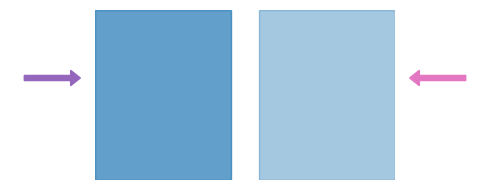

In [5]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(5, 2), sharey=True, sharex=True, width_ratios=[1, 2, 2, 1])

# river inflows
ax[0].arrow(0.2, 0.6, 0.65, 0, width=0.03, color='tab:purple', alpha=1)
ax[3].arrow(0.8, 0.6, -0.65, 0, width=0.03, color='tab:pink', alpha=1)

ax[1].axhspan(0, 1, xmax=0.95, color='tab:blue', alpha=0.7)
ax[2].axhspan(0, 1, xmin=0.05, color='tab:blue', alpha=0.4)

for i in range(len(ax)):
    ax[i].set_xlim(0, 1)
    ax[i].set_ylim(0, 1)
    ax[i].axis('off')

plt.tight_layout(w_pad=1)
plt.savefig('../gallery/surf/2026_03_16/river_inflow.svg', bbox_inches='tight')
plt.show()

#### Surface cooling

Differential cooling

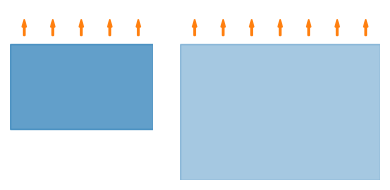

In [6]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(4, 2), sharey=True, width_ratios=[1, 1.4])

ax[0].axhspan(0.3, 0.8, color='tab:blue', alpha=0.7)
ax[1].axhspan(0, 0.8, color='tab:blue', alpha=0.4)

# surface cooling
for x in np.arange(0.1, 1.5, 0.2):
    ax[1].arrow(x, 0.85, 0, 0.05, width=0.01, color='tab:orange')
    if x < 1:
        ax[0].arrow(x, 0.85, 0, 0.05, width=0.01, color='tab:orange')

ax[0].set_xlim(0, 1)
ax[1].set_xlim(0, 1.4)

for i in range(len(ax)):
    ax[i].set_ylim(0, 1)
    ax[i].axis('off')

plt.tight_layout(w_pad=2)
plt.savefig('../gallery/surf/2026_03_16/surface_cooling.svg', bbox_inches='tight')
plt.show()

#### Winds

Differential deepening.  Internal seiche.

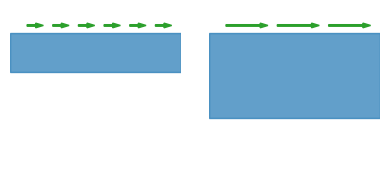

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(4, 2), sharey=True)

ax[0].axhspan(0.7, 0.95, color='tab:blue', alpha=0.7)
ax[1].axhspan(0.4, 0.95, color='tab:blue', alpha=0.7)

# low wind
ax[0].arrow(0.1, 1, 0.05, 0, width=0.01, color='tab:green')
ax[0].arrow(0.25, 1, 0.05, 0, width=0.01, color='tab:green')
ax[0].arrow(0.4, 1, 0.05, 0, width=0.01, color='tab:green')
ax[0].arrow(0.55, 1, 0.05, 0, width=0.01, color='tab:green')
ax[0].arrow(0.7, 1, 0.05, 0, width=0.01, color='tab:green')
ax[0].arrow(0.85, 1, 0.05, 0, width=0.01, color='tab:green')

# high wind
ax[1].arrow(0.1, 1, 0.2, 0, width=0.01, color='tab:green')
ax[1].arrow(0.4, 1, 0.2, 0, width=0.01, color='tab:green')
ax[1].arrow(0.7, 1, 0.2, 0, width=0.01, color='tab:green')

for i in range(len(ax)):
    ax[i].set_xlim(0, 1)
    ax[i].set_ylim(0, 1.1)
    ax[i].axis('off')

plt.tight_layout(w_pad=2)
plt.savefig('../gallery/surf/2026_03_16/differential_deepening.svg', bbox_inches='tight')
plt.show()

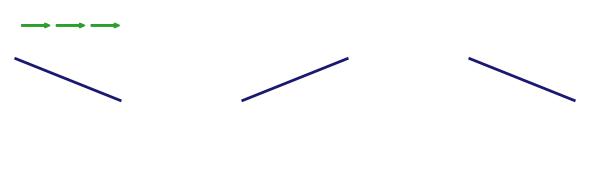

In [8]:
x = np.linspace(0.05, 0.95)
y = -0.3*x + 0.8

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(6, 2), sharey=True)

ax[0].plot(x, y, color='midnightblue', lw=2)
ax[1].plot(x, y[::-1], color='midnightblue', lw=2)
ax[2].plot(x, y, color='midnightblue', lw=2)

ax[0].arrow(0.1, 1, 0.2, 0, width=0.01, color='tab:green')
ax[0].arrow(0.4, 1, 0.2, 0, width=0.01, color='tab:green')
ax[0].arrow(0.7, 1, 0.2, 0, width=0.01, color='tab:green')

for i in range(len(ax)):
    ax[i].set_xlim(0, 1)
    ax[i].set_ylim(0, 1.1)
    ax[i].axis('off')

plt.tight_layout(w_pad=8)
plt.savefig('../gallery/surf/2026_03_16/seiche.svg', bbox_inches='tight')
plt.show()

#### CTD data and stratification

In [91]:
lake = 'Zugersee'
year = '2026'
date = '20260107'

dpath_L1 = f'Q:Messdaten/Aphys_Hypothesis_data/{lake}/{year}/CTD/{date}/L1'

In [92]:
for p in os.listdir(dpath_L1):
    fpath = os.path.join(dpath_L1, p)
    ctdreader = ewg.ctd_reader.CTDReader(lake, year, date, fpath)
    ds = ctdreader.load_from_L1()

    if ds.attrs['Profile name'] == 'P12':
        # data quality
        mask = (ds['depth'].notnull()) & (ds['Temp_qual'] == 0) & (ds['Cond_qual'] == 0)
        mask = mask & (ds['depth'] > 5)
        depth = ds['depth'][mask]
        temp = ds['Temp'][mask]
        cond = ds['Cond'][mask]
        rho = ds['rho'][mask]
        cond = ewg.signal.rolling_average(cond, depth, 1)
        rho = ewg.signal.savitzky_golay(rho)    # smoth density profile
        break

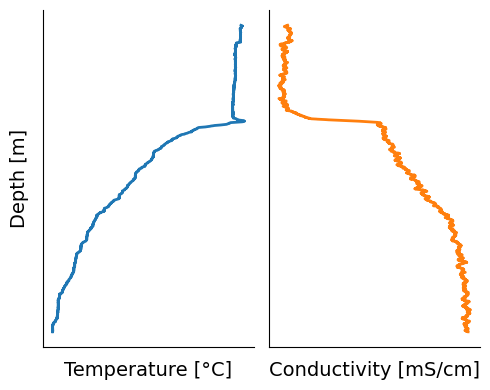

In [94]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(5, 4), sharey=True)

ax[0].plot(temp, depth, color='tab:blue', lw=2)
ax[1].plot(cond, depth, color='tab:orange', lw=2)

ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[0].set_xlabel('Temperature [°C]', fontsize=14, labelpad=10)
ax[1].set_xlabel('Conductivity [mS/cm]', fontsize=14, labelpad=10)

ax[0].invert_yaxis()

for i in range(len(ax)):
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.tight_layout()
plt.savefig('../gallery/surf/2026_03_16/ctd.svg', bbox_inches='tight')
plt.show()

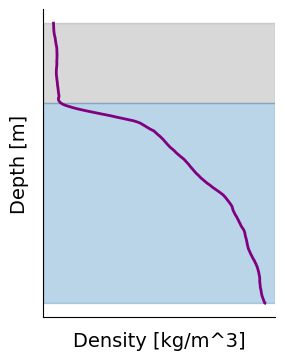

In [96]:
fig, ax = plt.subplots(figsize=(3, 4))

ax.axhspan(5, 42, color='gray', alpha=0.3)
ax.axhspan(42, 134, color='tab:blue', alpha=0.3)
ax.plot(rho, depth, color='purple', lw=2)

ax.set_xlabel('Density [kg/m^3]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_xticks([])
ax.set_yticks([])

ax.spines[['right', 'top']].set_visible(False)
ax.invert_yaxis()

plt.savefig('../gallery/surf/2026_03_16/stratified.svg', bbox_inches='tight')
plt.show()

#### Cross-sectional area

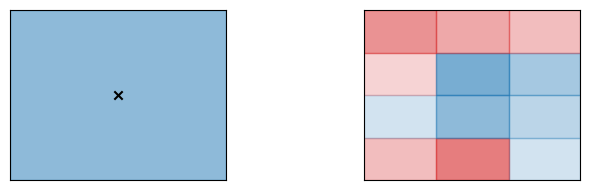

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6, 2), sharey=True, sharex=True)

ax[0].axvspan(0, 1, color='tab:blue', alpha=0.5)
ax[0].scatter(0.5, 0.5, marker='x', color='black')

ax[1].axhspan(0, 0.25, xmax=0.33, color='tab:red', alpha=0.3)
ax[1].axhspan(0, 0.25, xmin=0.33, xmax=0.67, color='tab:red', alpha=0.6)
ax[1].axhspan(0, 0.25, xmin=0.67, color='tab:blue', alpha=0.2)
ax[1].axhspan(0.25, 0.5, xmax=0.33, color='tab:blue', alpha=0.2)
ax[1].axhspan(0.25, 0.5, xmin=0.33, xmax=0.67, color='tab:blue', alpha=0.5)
ax[1].axhspan(0.25, 0.5, xmin=0.67, color='tab:blue', alpha=0.3)
ax[1].axhspan(0.5, 0.75, xmax=0.33, color='tab:red', alpha=0.2)
ax[1].axhspan(0.5, 0.75, xmin=0.33, xmax=0.67, color='tab:blue', alpha=0.6)
ax[1].axhspan(0.5, 0.75, xmin=0.67, color='tab:blue', alpha=0.4)
ax[1].axhspan(0.75, 1, xmax=0.33, color='tab:red', alpha=0.5)
ax[1].axhspan(0.75, 1, xmin=0.33, xmax=0.67, color='tab:red', alpha=0.4)
ax[1].axhspan(0.75, 1, xmin=0.67, color='tab:red', alpha=0.3)


for i in range(len(ax)):
    ax[i].set_xlim(0, 1)
    ax[i].set_ylim(0, 1)
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.tight_layout(w_pad=10)
plt.savefig('../gallery/surf/2026_03_16/flux_dA.svg', bbox_inches='tight')
plt.show()

#### Year-round timeline

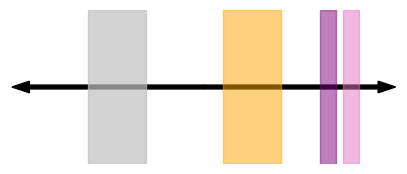

In [10]:
fig, ax = plt.subplots(figsize=(5, 2))

ax.arrow(0.5, 0, -0.45, 0, width=0.01, color='black')
ax.arrow(0.5, 0, 0.45, 0, width=0.01, color='black')

ax.axvspan(0.2, 0.35, color='silver', alpha=0.7)
ax.axvspan(0.55, 0.7, color='orange', alpha=0.5)
ax.axvspan(0.8, 0.84, color='purple', alpha=0.5)
ax.axvspan(0.86, 0.9, color='tab:pink', alpha=0.5)

ax.set_xlim(0, 1)
ax.set_ylim(-0.2, 0.2)
ax.axis('off')

plt.savefig('../gallery/surf/2026_03_16/time_period.svg', bbox_inches='tight')
plt.show()

#### Spatial variability

Compare flow speed at center and east moorings within constriciton.  Common depth range (116-127 meters), first week of December.

In [11]:
lake = 'Zugersee'
year = '2026'
date = '20260114'

d_min = 116
d_max = 127

In [12]:
location = 'LZE'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
deploy, _ = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
adcp = mreader.get_adcps()[0]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
t_end = ds.time.values.max() + pd.Timedelta(minutes=5)       # add 5 minutes to get equal samples
ds = ds.sel(time=slice(t_start, t_end))
ds_e = ds.sel(range=slice(d_max, d_min))


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZE/L0\3U16576.000 ...


In [13]:
location = 'LZC'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
adcp = mreader.get_adcps()[-1]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(time=slice(t_start, t_end))
ds_c = ds.sel(range=slice(d_max, d_min))


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


In [14]:
# shared time axis as mean of each instruments times
time_shared = np.mean([ds_e.time.values.astype('int64'), ds_c.time.values.astype('int64')], axis=0).astype('datetime64[ns]')
ds_c = ds_c.assign_coords(time=time_shared)
ds_e = ds_e.assign_coords(time=time_shared)

uc = ds_c.vel.sel(dir='E')
vc = ds_c.vel.sel(dir='N')
speed_c = np.sqrt(uc**2 + vc**2)

ue = ds_e.vel.sel(dir='E')
ve = ds_e.vel.sel(dir='N')
speed_e = np.sqrt(ue**2 + ve**2)

sc_sel = speed_c.mean(dim='range').sel(time=slice('2025-12-01', '2025-12-07'))
se_sel = speed_e.mean(dim='range').sel(time=slice('2025-12-01', '2025-12-07'))

# 1-hour rolling average
sc_ra = sc_sel.rolling(time=6, center=True).mean()
se_ra = se_sel.rolling(time=5, center=True).mean()

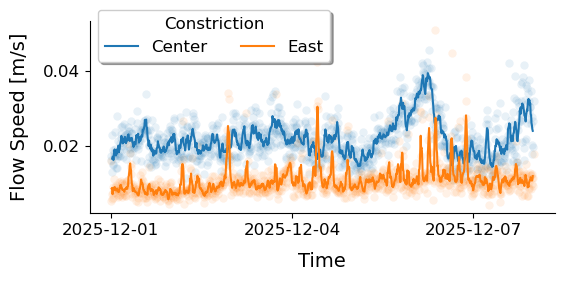

In [15]:
fig, ax = plt.subplots(figsize=(6, 2.5))

sns.scatterplot(x=sc_sel.time, y=sc_sel, alpha=0.1, color='tab:blue', ax=ax)
sns.scatterplot(x=se_sel.time, y=se_sel, alpha=0.1, color='tab:orange', ax=ax)


sns.lineplot(x=sc_ra.time, y=sc_ra, label='Center', color='tab:blue', ax=ax)
sns.lineplot(x=se_ra.time, y=se_ra, label='East', color='tab:orange', ax=ax)


ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.set_xticks(ax.get_xticks()[::3])
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.legend(ncols=2, title='Constriction', fontsize=12, title_fontsize=12, shadow=True, fancybox=True, loc='upper left', bbox_to_anchor=(0, 1.1))

plt.savefig('../gallery/surf/2026_03_16/spatial_CE.svg', bbox_inches='tight')
plt.show()

#### Temporal variability

North-south flow velocity at 80 meters depth at center mooring within constriction.  First two weeks of January.

In [37]:
lake = 'Zugersee'
location = 'LZC'
year = '2026'
date = '20260114'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve
mxsc, mysc =  mreader.get_swiss_coords()
bathy = xr.open_dataset(mreader.BATHY_PATH.format(lake=lake))
adcps = mreader.get_adcps()
thermistors = mreader.get_thermistors()
oxygen_loggers = mreader.get_oxygen_loggers()

# linear regression from known depths
sensor_depths = mreader.extract_sensor_depths()
m, b, _, _, _ = scipy.stats.linregress(sensor_depths.depth_md, sensor_depths.depth_sensor)
instruments = mreader.get_instruments(pandas=True)
instruments['depth_md'] = mreader.total_depth - instruments['mab']
instruments['depth_lr'] = m * instruments['depth_md'] + b

# use known depths where available
depth_table = pd.merge(instruments, sensor_depths, how='outer')
depth_table['depth'] = depth_table['depth_sensor'].fillna(depth_table['depth_lr']).round(1)
depth_table = depth_table.sort_values('depth')


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\12U8315.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U672.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\6D1728.000 ...


C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\adcp_reader.py:81: UserWarning: No pressure measurements on ADCP, calculating depth from metadata.
  warnings.warn('No pressure measurements on ADCP, calculating depth from metadata.')



Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


In [38]:
all_adcp = []
for adcp in adcps:
    serial_id = adcp['serial_id']
    areader = ewg.adcp_reader.ADCPReader(serial_id, lake, location, year, date)
    fpath = areader.locate_data_file('L0')
    ds = areader.load_from_L0()
    ds = ds.expand_dims(serial_id=[ds.attrs['serialnum']])
    areader.depth = depth_table.loc[depth_table['serial_id'] == serial_id, 'depth'].iloc[0]
    ds = areader.range_to_depth(ds)
    ds['range'] = ds['range'].round(0)
    ds = areader.run_qa(ds)
    ds = ds.sel(time=slice(t_start, t_end))
    all_adcp.append(ds)

# shared time axis as mean of each instruments times
time_shared = (np.mean([ds.time.values.astype('int64') for ds in all_adcp], axis=0).astype('datetime64[ns]'))
all_adcp_aligned = [ds.assign_coords(time=time_shared) for ds in all_adcp]

# concatenate datasets and average common range bins
ds_combined = xr.concat(all_adcp_aligned, dim='range')
ds_combined = ds_combined.sortby('range')
ds_combined = ds_combined.groupby('range').mean()

# don't interplate over gap from opposite looking ADCPs in double frame
gap = np.arange(69, 73)
full_range = np.sort(np.concatenate([ds_combined.range.values, gap]))
ds_full = ds_combined.reindex(range=full_range)

# drop range bins with dubious data
bad_ranges = [68, 128, 129, 130]
ds_full = ds_full.drop_sel(range=bad_ranges)


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\12U8315.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U672.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\6D1728.000 ...


C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\adcp_reader.py:81: UserWarning: No pressure measurements on ADCP, calculating depth from metadata.
  warnings.warn('No pressure measurements on ADCP, calculating depth from metadata.')



Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


C:\Users\herremha\AppData\Local\Temp\ipykernel_12616\2128449737.py:20: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'serial_id' ('serial_id',) The recommendation is to set join explicitly for this case.
  ds_combined = xr.concat(all_adcp_aligned, dim='range')


In [39]:
v = ds_full.vel.sel(dir='N').mean(dim='serial_id')
v_sel = v.sel(time=slice('2026-01-01', None)).sel(range=80, method='nearest')
v_ra = v_sel.rolling(time=6, center=True).mean()

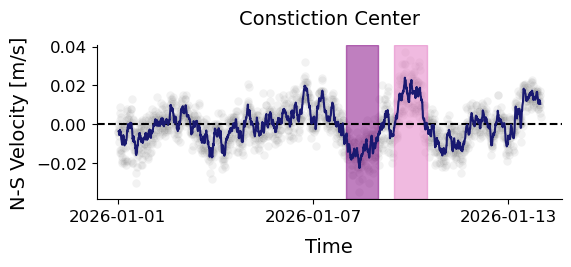

In [40]:
fig, ax = plt.subplots(figsize=(6, 2))

ax.axhline(0, color='black', linestyle='--')
sns.scatterplot(x=v_sel.time, y=v_sel, color='gray', alpha=0.1, ax=ax)
sns.lineplot(x=v_ra.time, y=v_ra, color='midnightblue', ax=ax)

ax.axvspan('2026-01-08', '2026-01-09', color='purple', alpha=0.5)
ax.axvspan('2026-01-09 12:00', '2026-01-10 12:00', color='tab:pink', alpha=0.5)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('N-S Velocity [m/s]', fontsize=14, labelpad=5)
ax.set_title('Constiction Center', fontsize=14, pad=15)
ax.set_xticks(ax.get_xticks()[::3])
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
#plt.savefig('../gallery/surf/2026_03_16/temporal_C.svg', bbox_inches='tight')
plt.show()

#### ADCP Data

Timeseries and shear flow visualizations.

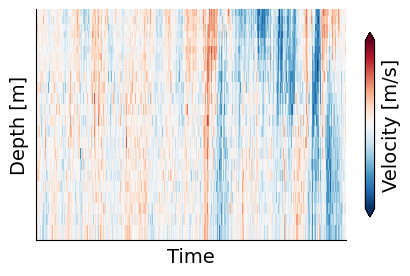

In [42]:
v = ds_full.vel.sel(dir='N').mean(dim='serial_id')
v_sel = v.sel(range=slice(35, 65)).sel(time=slice('2025-12-01', None))

fig, ax = plt.subplots(figsize=(5, 3))

pc = v_sel.plot(x='time', y='range', cmap='RdBu_r', vmin=-0.05, vmax=0.05, cbar_kwargs={'shrink': 0.8}, ax=ax, rasterized=True)
pc.colorbar.ax.set_ylabel('Velocity [m/s]', fontsize=14, labelpad=5)
pc.colorbar.ax.tick_params(right=False, labelright=False)

ax.set_xlabel('Time', fontsize=14, labelpad=5)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=5)
ax.set_title('')
ax.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

ax.spines[['top', 'right']].set_visible(False)
#for spine in pc.colorbar.ax.spines.values():
#    spine.set_visible(False)
ax.invert_yaxis()

plt.savefig('../gallery/surf/2026_03_16/adcp_ts.svg', bbox_inches='tight')
plt.show()

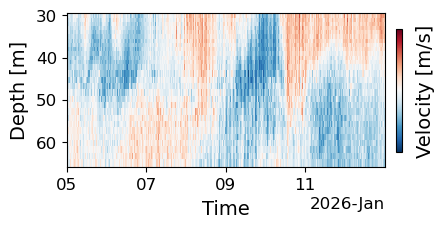

In [44]:
v_sel = v.sel(time=slice('2026-01-05', '2026-01-12')).sel(range=slice(30, 65))

fig, ax = plt.subplots(figsize=(5, 2))

pc = v_sel.plot(x='time', y='range', cmap='RdBu_r', vmin=-0.06, vmax=0.06, cbar_kwargs={'shrink': 0.8, 'pad':0.03}, ax=ax, rasterized=True)
pc.colorbar.ax.set_ylabel('Velocity [m/s]', fontsize=14, labelpad=10)
pc.colorbar.ax.tick_params(right=False, labelright=False)
ax.xaxis.get_offset_text().set_fontsize(12)

ax.set_xlabel('Time', fontsize=14, labelpad=5)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=5)
ax.set_title('')
ax.tick_params(axis='both', labelsize=12)
ax.set_xticks(ax.get_xticks()[::2])

ax.invert_yaxis()
plt.savefig('../gallery/surf/2026_03_16/shear_flow.svg', bbox_inches='tight')
plt.show()

#### Turbulence

Dissipation rate of turbulent kinetic energy from 13.1.2026 and 13.2.2026 campaigns, profiles from south basin, constriction center and west.

Temperature profiles from FP07.

In [45]:
lake = 'Zugersee'
year = '2026'
date = '20260113'

dpath_L2 = f'Q:Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Microstructure/{date}/L2'
fpaths = glob(f'{dpath_L2}/*.nc')

In [46]:
eps_c, chi_c, K_c = [], [], []
eps_w, chi_w, K_w = [], [], []
eps_s, chi_s, K_s = [], [], []
for fpath in fpaths:
    ds = xr.open_dataset(fpath)
    mask = (ds['BINNED_flag_T1'] == 0) & (ds['BINNED_flag_T2'] == 0) & (ds['BINNED_depth'] > 5)

    eps = xr.concat([ds['BINNED_eps_T1'][mask], ds['BINNED_eps_T2'][mask]], dim='sensor').mean(dim='sensor')
    chi = xr.concat([ds['BINNED_Xi_T1'][mask], ds['BINNED_Xi_T2'][mask]], dim='sensor').mean(dim='sensor')
    K = xr.concat([ds['BINNED_KOsbornCox_T1'][mask], ds['BINNED_KOsbornCox_T2'][mask]], dim='sensor').mean(dim='sensor')

    # VMPS
    if 'DAT_053' in fpath:
        eps_s.append(eps)
        chi_s.append(chi)
        K_s.append(K)

    # VMPC
    elif 'DAT_055' in fpath or 'DAT_059' in fpath:
        eps_c.append(eps)
        chi_c.append(chi)
        K_c.append(K)

    # VMPW
    elif 'DAT_057' in fpath:
        eps_w.append(eps)
        chi_w.append(chi)
        K_w.append(K)

eps_s = xr.concat(eps_s, dim='BINNED_depth').sortby('BINNED_depth')
eps_c = xr.concat(eps_c, dim='BINNED_depth').sortby('BINNED_depth')
eps_w = xr.concat(eps_w, dim='BINNED_depth').sortby('BINNED_depth')

# 5 meter bins
bins_s = np.arange(0, eps_s['BINNED_depth'].max() + 5, 5)
eps_s_avg = eps_s.groupby_bins("BINNED_depth", bins_s).median()
bc_s = np.array([b.mid for b in eps_s_avg['BINNED_depth_bins'].values])

bins_c = np.arange(0, eps_c['BINNED_depth'].max() + 5, 5)
eps_c_avg = eps_c.groupby_bins("BINNED_depth", bins_c).median()
bc_c = np.array([b.mid for b in eps_c_avg['BINNED_depth_bins'].values])

bins_w = np.arange(0, eps_w['BINNED_depth'].max() + 5, 5)
eps_w_avg = eps_w.groupby_bins("BINNED_depth", bins_w).median()
bc_w = np.array([b.mid for b in eps_w_avg['BINNED_depth_bins'].values])

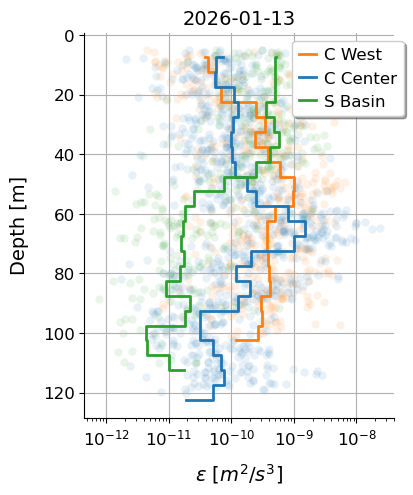

In [48]:
fig, ax = plt.subplots(figsize=(4, 5))

# epsilon
sns.scatterplot(x=eps_w, y=eps_w['BINNED_depth'], color='tab:orange', alpha=0.1, ax=ax)
sns.lineplot(x=eps_w_avg, y=bc_w, orient='y', color='tab:orange', linewidth=2, drawstyle="steps-mid", ax=ax, label='C West')

sns.scatterplot(x=eps_c, y=eps_c['BINNED_depth'], color='tab:blue', alpha=0.1, ax=ax)
sns.lineplot(x=eps_c_avg, y=bc_c, orient='y', color='tab:blue', linewidth=2, drawstyle="steps-mid", ax=ax, label='C Center')

sns.scatterplot(x=eps_s, y=eps_s['BINNED_depth'], color='tab:green', alpha=0.1, ax=ax)
sns.lineplot(x=eps_s_avg, y=bc_s, orient='y', color='tab:green', linewidth=2, drawstyle="steps-mid", ax=ax, label='S Basin')

ax.set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('2026-01-13', fontsize=14)

ax.invert_yaxis()
ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=12)
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.legend(fontsize=12, ncols=1, shadow=True, loc='upper center', bbox_to_anchor=(0.85, 1), 
          handlelength=1.0, handletextpad=0.5, columnspacing=1)

plt.savefig('../gallery/surf/2026_03_16/epsilon.svg', bbox_inches='tight')
plt.show()

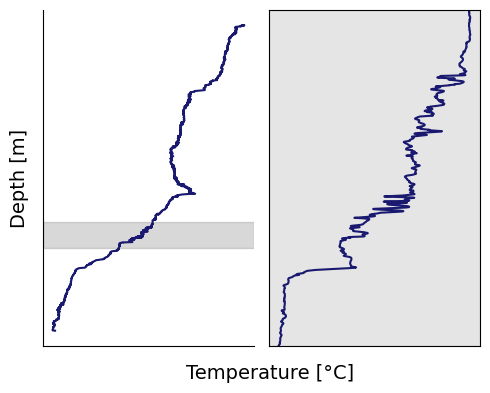

In [52]:
mask_temp = ds['FAST_depth'] > 5
mask_zoom = (ds['FAST_depth'] > 80) & (ds['FAST_depth'] < 90)

# temperature
temp = xr.concat([ds['FAST_fast_T1'], ds['FAST_fast_T2']], dim='sensor').mean(dim='sensor')

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(5, 4))

ax[0].axhspan(80, 90, color='gray', alpha=0.3)
ax[0].plot(temp[mask_temp], ds['FAST_depth'][mask_temp], color='midnightblue')
ax[1].axhspan(80, 90, color='gray', alpha=0.2)
ax[1].plot(temp[mask_zoom], ds['FAST_depth'][mask_zoom], color='midnightblue')

ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
fig.supxlabel('Temperature [°C]', fontsize=14, x=0.55, y=0.03)

ax[0].spines[['right', 'top']].set_visible(False)
ax[1].set_ylim(80, 90)
for i in range(len(ax)):
    ax[i].invert_yaxis()
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.tight_layout()
plt.savefig('../gallery/surf/2026_03_16/microctd.svg', bbox_inches='tight')
plt.show()

In [53]:
lake = 'Zugersee'
year = '2026'
date = '20260213'

dpath_L2 = f'Q:Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Microstructure/{date}/Level2'
fpaths = glob(f'{dpath_L2}/*.nc')

In [54]:
eps_c, chi_c, K_c = [], [], []
eps_w, chi_w, K_w = [], [], []
eps_s, chi_s, K_s = [], [], []
for fpath in fpaths:
    ds = xr.open_dataset(fpath)
    mask = (ds['BINNED_flag_T1'] == 0) & (ds['BINNED_flag_T2'] == 0) & (ds['BINNED_depth'] > 5)

    eps = xr.concat([ds['BINNED_eps_T1'][mask], ds['BINNED_eps_T2'][mask]], dim='sensor').mean(dim='sensor')
    chi = xr.concat([ds['BINNED_Xi_T1'][mask], ds['BINNED_Xi_T2'][mask]], dim='sensor').mean(dim='sensor')
    K = xr.concat([ds['BINNED_KOsbornCox_T1'][mask], ds['BINNED_KOsbornCox_T2'][mask]], dim='sensor').mean(dim='sensor')

    # VMPS
    if 'DAT_095' in fpath:
        eps_s.append(eps)
        chi_s.append(chi)
        K_s.append(K)

    # VMPC
    elif 'DAT_093' in fpath:
        eps_c.append(eps)
        chi_c.append(chi)
        K_c.append(K)

    # VMPW
    elif 'DAT_094' in fpath:
        eps_w.append(eps)
        chi_w.append(chi)
        K_w.append(K)

eps_s = xr.concat(eps_s, dim='BINNED_depth').sortby('BINNED_depth')
eps_c = xr.concat(eps_c, dim='BINNED_depth').sortby('BINNED_depth')
eps_w = xr.concat(eps_w, dim='BINNED_depth').sortby('BINNED_depth')

# 5 meter bins
bins_s = np.arange(0, eps_s['BINNED_depth'].max() + 5, 5)
eps_s_avg = eps_s.groupby_bins("BINNED_depth", bins_s).median()
bc_s = np.array([b.mid for b in eps_s_avg['BINNED_depth_bins'].values])

bins_c = np.arange(0, eps_c['BINNED_depth'].max() + 5, 5)
eps_c_avg = eps_c.groupby_bins("BINNED_depth", bins_c).median()
bc_c = np.array([b.mid for b in eps_c_avg['BINNED_depth_bins'].values])

bins_w = np.arange(0, eps_w['BINNED_depth'].max() + 5, 5)
eps_w_avg = eps_w.groupby_bins("BINNED_depth", bins_w).median()
bc_w = np.array([b.mid for b in eps_w_avg['BINNED_depth_bins'].values])

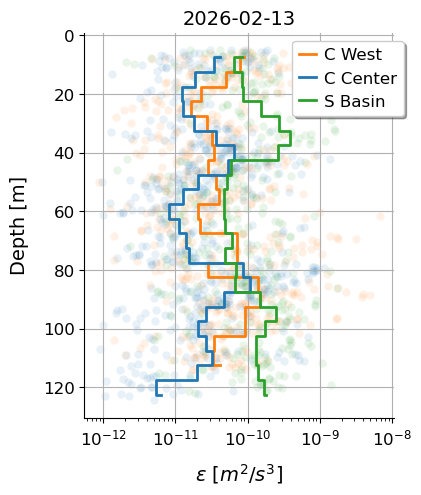

In [56]:
fig, ax = plt.subplots(figsize=(4, 5))

# epsilon
sns.scatterplot(x=eps_w, y=eps_w['BINNED_depth'], color='tab:orange', alpha=0.1, ax=ax)
sns.lineplot(x=eps_w_avg, y=bc_w, orient='y', color='tab:orange', linewidth=2, drawstyle="steps-mid", ax=ax, label='C West')

sns.scatterplot(x=eps_c, y=eps_c['BINNED_depth'], color='tab:blue', alpha=0.1, ax=ax)
sns.lineplot(x=eps_c_avg, y=bc_c, orient='y', color='tab:blue', linewidth=2, drawstyle="steps-mid", ax=ax, label='C Center')

sns.scatterplot(x=eps_s, y=eps_s['BINNED_depth'], color='tab:green', alpha=0.1, ax=ax)
sns.lineplot(x=eps_s_avg, y=bc_s, orient='y', color='tab:green', linewidth=2, drawstyle="steps-mid", ax=ax, label='S Basin')

ax.set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('2026-02-13', fontsize=14)

ax.invert_yaxis()
ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=12)
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.legend(fontsize=12, ncols=1, shadow=True, loc='upper center', bbox_to_anchor=(0.85, 1), 
          handlelength=1.0, handletextpad=0.5, columnspacing=1)

plt.savefig('../gallery/surf/2026_03_16/epsilon2.svg', bbox_inches='tight')
plt.show()

#### Overturns/instabilities

From consriction center CTD profiles.  Temperature on 12.1.2026, oxygen on 7.1.2026.

In [58]:
lake = 'Zugersee'
year = '2026'
date = '20260112'

dpath_L1 = f'Q:Messdaten/Aphys_Hypothesis_data/{lake}/{year}/CTD/{date}/L1'

In [59]:
data = []
for p in os.listdir(dpath_L1):
    fpath = os.path.join(dpath_L1, p)
    ctdreader = ewg.ctd_reader.CTDReader(lake, year, date, fpath)
    ds = ctdreader.load_from_L1()

    if ds.attrs['Profile name'] == 'P06':
        # data quality
        mask = (ds['depth'].notnull()) & (ds['Temp_qual'] == 0)
        mask = mask & (ds['depth'] > 35) & (ds['depth'] < 85)
        depth = ds['depth'][mask]
        temp = ds['Temp'][mask]

        dat = pd.DataFrame({
            'depth': depth,
            'temp': temp
        })
        dat['time'] = ds.attrs['Time of measurement (local)']
        data.append(dat)

data = pd.concat(data, ignore_index=True)

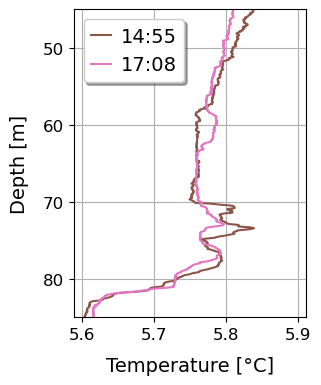

In [61]:
fig, ax = plt.subplots(figsize=(3, 4))
palette = sns.color_palette('tab10')

sns.lineplot(data, x='temp', y='depth', orient='y', hue='time', 
             hue_order=['14:55', '17:08'], palette=palette[5:7], ax=ax)

ax.set_xlabel('Temperature [°C]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)
ax.set_yticks(ax.get_yticks()[::])
ax.set_ylim(45, 85)
ax.invert_yaxis()
ax.grid(True)
ax.legend(fontsize=14, shadow=True, handlelength=1.0, handletextpad=0.5)
plt.savefig('../gallery/surf/2026_03_16/temp_constriction.svg', bbox_inches='tight')
plt.show()

In [62]:
lake = 'Zugersee'
year = '2026'
date = '20260107'

dpath_L1 = f'Q:Messdaten/Aphys_Hypothesis_data/{lake}/{year}/CTD/{date}/L1'

In [63]:
data = []
for p in os.listdir(dpath_L1):
    fpath = os.path.join(dpath_L1, p)
    ctdreader = ewg.ctd_reader.CTDReader(lake, year, date, fpath)
    ds = ctdreader.load_from_L1()

    if ds.attrs['Profile name'] == 'P06':
        # data quality
        mask = (ds['depth'].notnull()) & (ds['DO_mg_qual'] == 0)
        mask = mask & (ds['depth'] > 50) & (ds['depth'] < 90)
        depth = ds['depth'][mask]
        do = ds['DO_mg'][mask]

        dat = pd.DataFrame({
            'depth': depth,
            'do': do
        })
        dat['time'] = ds.attrs['Time of measurement (local)']
        data.append(dat)

data = pd.concat(data, ignore_index=True)

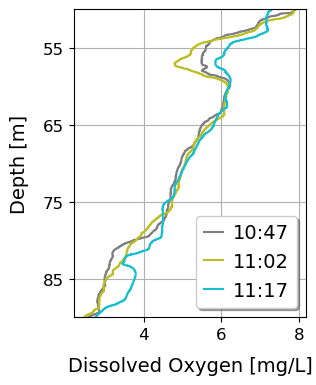

In [65]:
fig, ax = plt.subplots(figsize=(3, 4))
palette = sns.color_palette('tab10')

sns.lineplot(data, x='do', y='depth', orient='y', hue='time',
              hue_order=['10:47', '11:02', '11:17'], palette=palette[7:10], ax=ax)

ax.set_xlabel('Dissolved Oxygen [mg/L]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)
ax.set_yticks(ax.get_yticks()[::2])
ax.set_ylim(50, 90)
ax.invert_yaxis()
ax.grid(True)
ax.legend(fontsize=14, shadow=True, handlelength=1.0, handletextpad=0.5)
plt.savefig('../gallery/surf/2026_03_16/do_constriction.svg', bbox_inches='tight')
plt.show()

#### Lateral intrusion

Temperature, conductivity, and dissolved oxygen from south basin CTD profile on 13.2.2026.

In [73]:
lake = 'Zugersee'
year = '2026'
date = '20260213'

dpath_L1 = f'Q:Messdaten/Aphys_Hypothesis_data/{lake}/{year}/CTD/{date}/L1'

In [74]:
for p in os.listdir(dpath_L1):
    fpath = os.path.join(dpath_L1, p)
    ctdreader = ewg.ctd_reader.CTDReader(lake, year, date, fpath)
    ds = ctdreader.load_from_L1()

    if ds.attrs['Profile name'] == 'VMPS':
        # data quality
        mask = (ds['depth'].notnull()) & (ds['Temp_qual'] == 0) & (ds['Cond_qual'] == 0) & (ds[f'DO_mg_qual'] == 0)
        mask = mask & (ds['depth'] > 5)
        depth = ds['depth'][mask]
        temp = ds['Temp'][mask]
        cond = ds['Cond'][mask]
        rho = ds['rho'][mask]
        do = ds['DO_mg'][mask]

        # smoth density and salinity profile
        rho = xr.DataArray(ewg.signal.rolling_average(rho, depth, 1), dims='time', coords={'time': rho['time'].values}, name='rho')
        cond = xr.DataArray(ewg.signal.rolling_average(cond, depth, 1), dims='time', coords={'time': cond['time'].values}, name='cond')

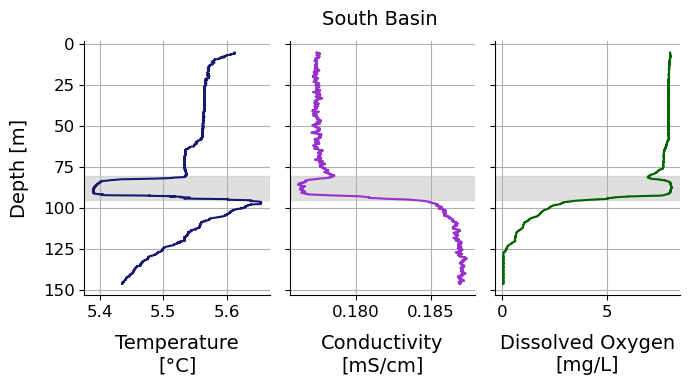

In [76]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(7, 4), sharey=True)

ax[0].plot(temp, depth, color='midnightblue')
ax[1].plot(cond, depth, color='darkorchid')
ax[2].plot(do, depth, color='darkgreen')

ax[0].set_xlabel('Temperature\n[°C]', fontsize=14, labelpad=10)
ax[1].set_xlabel('Conductivity\n[mS/cm]', fontsize=14, labelpad=10)
ax[2].set_xlabel('Dissolved Oxygen\n[mg/L]', fontsize=14, labelpad=10)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

for i in range(len(ax)):
    ax[i].axhspan(80, 95, color='silver', alpha=0.5)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

fig.suptitle('South Basin', fontsize=14, x=0.55, y=0.95)
ax[0].invert_yaxis()
plt.tight_layout()
plt.savefig('../gallery/surf/2026_03_16/intrusion_sbasin.svg', bbox_inches='tight')
plt.show()

#### Anoxic depth

Anoxic depth from south basin CTD profiles.

In [70]:
def calculate_transect_min_do(dpath_L1):
    # transect minimum
    min_do = []
    for p in os.listdir(dpath_L1):
        fpath = os.path.join(dpath_L1, p)
        
        ctdreader = ewg.ctd_reader.CTDReader(lake, year, date, fpath)
        ds = ctdreader.load_from_L1()

        # data quality
        mask = (ds['depth'].notnull()) & (ds[f'DO_mg_qual'] == 0)
        do = ds['DO_mg'][mask]
        min_do.append(do.min().item())

    return min(min_do)

In [77]:
years = ['2025', '2026']
anoxia_data = []
for year in years:
    ctd_root = f'Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/{year}/CTD'

    for date in tqdm(os.listdir(ctd_root)):
        if date > '20251029' and date < '20260309':
            dpath_L1 = os.path.join(ctd_root, date, 'L1')
            for p in os.listdir(dpath_L1):
                fpath = os.path.join(dpath_L1, p)
                ctdreader = ewg.ctd_reader.CTDReader(lake, year, date, fpath)
                ds = ctdreader.load_from_L1()

                ysc = int(ds.attrs['Y Coordinate (CH1903)']) + int(1e6)
                if ysc < 1217437:
                    min_do = calculate_transect_min_do(dpath_L1)
                    
                    # data quality
                    mask = (ds['depth'].notnull()) & (ds[f'DO_mg_qual'] == 0)
                    depth_ = ds['depth'][mask]
                    do_ = ds['DO_mg'][mask]

                    try:
                        idx = np.where(do_ <= min_do + 0.2)[0][0]
                        z = depth_[idx].item()
                    except IndexError:
                        z = np.nan

                    anoxia_data.append({
                        'date': pd.to_datetime(date, format='%Y%m%d'),
                        'anoxic_depth': z
                    })

anoxia_data = pd.DataFrame(anoxia_data)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

C:\Users\herremha\AppData\Local\Temp\ipykernel_12616\2047405037.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  sns.scatterplot(anoxia_data.query("date == '2026-02-13'"), x='date', y='anoxic_depth', marker='X', s=100, color='limegreen', zorder=2, ax=ax[1])


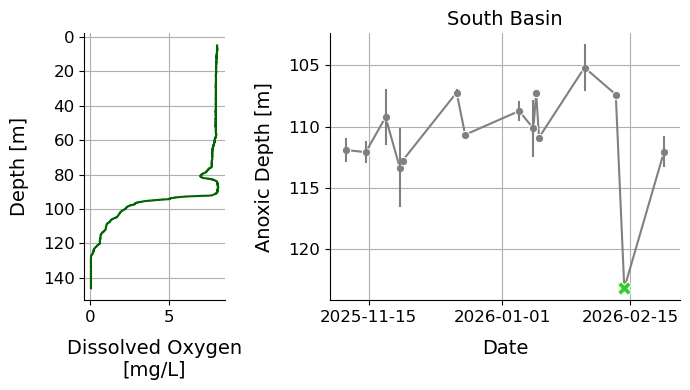

In [78]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 4), width_ratios=[1, 2.5])

ax[0].plot(do, depth, color='darkgreen')

sns.lineplot(anoxia_data, x='date', y='anoxic_depth', marker='o', errorbar=('se', 1), err_style='bars', color='gray', ax=ax[1])
sns.scatterplot(anoxia_data.query("date == '2026-02-13'"), x='date', y='anoxic_depth', marker='X', s=100, color='limegreen', zorder=2, ax=ax[1])

ax[0].set_xlabel('Dissolved Oxygen\n[mg/L]', fontsize=14, labelpad=10)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[1].set_xlabel('Date', fontsize=14, labelpad=10)
ax[1].set_ylabel('Anoxic Depth [m]', fontsize=14, labelpad=10)
ax[1].set_title('South Basin', fontsize=14)
ax[1].set_xticks(ax[1].get_xticks()[::3])

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].invert_yaxis()
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

plt.tight_layout()
#plt.savefig('../gallery/surf/2026_03_16/anoxia_a3.svg', bbox_inches='tight')
plt.show()

#### Deep water renewal

Oxygen and temperature from constriction mooring 10.1.2026 to 12.1.2026.  North-south and vertical velocity starting from maximum of deep oxygen.

In [79]:
lake = 'Zugersee'
year = '2026'
date = '20260114'

t_start = '2026-01-10'
t_end = '2026-01-12'

In [83]:
ds_chain = []
for ol in oxygen_loggers:

    oreader = ewg.o2_reader.O2Reader(ol['serial_id'], lake, location, year, date)
    fpath = os.path.join(mreader.dpath_L0, f"7450-{ol['serial_id']}/Cat.txt")
    oreader.depth = depth_table.loc[depth_table['serial_id'] == ol['serial_id'], 'depth'].iloc[0]
    ds = oreader.load_from_L0()
    ds = ds.sel(time=slice(t_start, t_end))
    #ds['d_oxygen_conc'] *= (1000/32)    # conver to umol/L
    ds_chain.append(ds)

ds_do = mreader.create_instrument_chain(ds_chain)

# time of maximum oxygen at depth
ds_do_sel = ds_do.sel(depth=ds_do.depth.min().item())
idx = ds_do_sel.d_oxygen_conc.argmax()
t0 = ds_do_sel.d_oxygen_conc[idx].time.values

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


In [84]:
ds_chain = []
for t in thermistors:

    treader = ewg.thermistor_reader.ThermistorReader(t['serial_id'], lake, location, year, date)
    treader.depth = depth_table.loc[depth_table['serial_id'] == t['serial_id'], 'depth'].iloc[0]
    if treader.depth >= ds_do.depth.min().item() and treader.depth <= ds_do.depth.max().item():
        ds = treader.load_from_L0()
        ds = ds.sel(time=slice(t_start, t_end))
        ds_chain.append(ds)

ds_temp = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


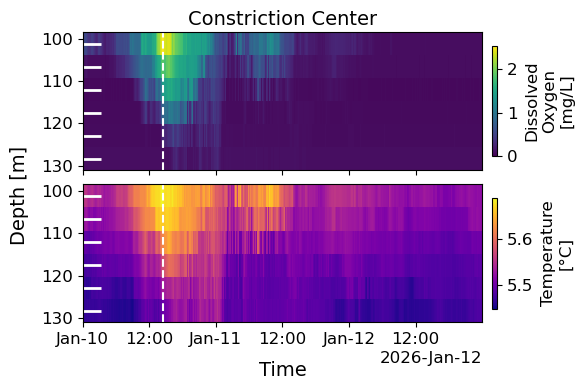

In [86]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), sharex=True, sharey=True)

ax[0].axvline(t0, color='white', linestyle='--')
# oxygen and oxygen logger depths
im = ds_do.d_oxygen_conc.plot(cmap='viridis', vmin=0, cbar_kwargs={'shrink': 0.8, 'pad':0.02}, rasterized=True, ax=ax[0])
im.colorbar.ax.tick_params(labelsize=12)
im.colorbar.ax.set_ylabel('Dissolved\nOxygen\n[mg/L]', fontsize=12, labelpad=5)
for d in ds_do.depth:
    ax[0].plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax[0].get_yaxis_transform(), clip_on=False)

ax[1].axvline(t0, color='white', linestyle='--')
# temperature and thermistor depths
im = ds_temp.temp.plot(cmap='plasma', cbar_kwargs={'shrink': 0.8, 'pad':0.02}, rasterized=True, ax=ax[1])
im.colorbar.ax.tick_params(labelsize=12)
im.colorbar.ax.set_ylabel('Temperature\n[°C]', fontsize=12, labelpad=5)
ax[1].xaxis.get_offset_text().set_fontsize(12)
for d in ds_temp.depth:
    ax[1].plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax[1].get_yaxis_transform(), clip_on=False)

ax[0].set_xlabel('')
ax[1].set_xlabel('Time', fontsize=14, labelpad=10)
ax[0].set_ylabel('')
ax[1].set_ylabel('')
ax[0].set_title('Constriction Center', fontsize=14, pad=5)
ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='both', labelsize=12)
ax[0].invert_yaxis()

fig.supylabel('Depth [m]', fontsize=14, x=0.03)

plt.tight_layout(h_pad=0.5)
plt.savefig('../gallery/surf/2026_03_16/do_temp_renewal.svg', bbox_inches='tight')
plt.show()

In [87]:
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(range=slice(ds_do.depth.max().item(), ds_do.depth.min().item()))
ds_adcp = ds.sel(time=slice(t0, t_end))

v_avg = ds_adcp.vel.sel(dir='N').mean(dim='range')
v_ra = v_avg.rolling(time=6, center=True).mean()    # 1-hour rolling average
w_avg = ds_adcp.vel.sel(dir='U').mean(dim='range')
w_ra = w_avg.rolling(time=6, center=True).mean()


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


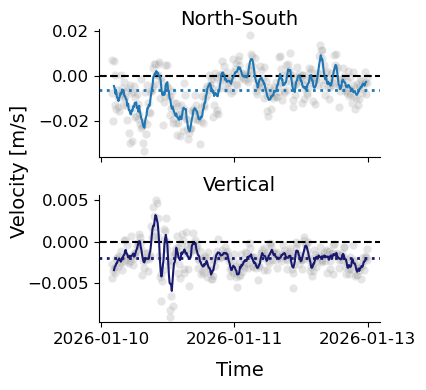

In [88]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(4.5, 4), sharex=True)

ax[0].axhline(0, color='black', linestyle='--')
ax[0].axhline(v_avg.mean().item(), color='tab:blue', linestyle=':', lw=2)
sns.scatterplot(x=v_avg.time, y=v_avg, alpha=0.3, color='darkgray', ax=ax[0])
sns.lineplot(x=v_ra.time, y=v_ra, color='tab:blue', ax=ax[0])

ax[1].axhline(0, color='black', linestyle='--')
ax[1].axhline(w_avg.mean().item(), color='midnightblue', linestyle=':', lw=2)
sns.scatterplot(x=w_avg.time, y=w_avg, alpha=0.3, color='darkgray', ax=ax[1])
sns.lineplot(x=w_ra.time, y=w_ra, color='midnightblue', ax=ax[1])


ax[1].set_xlabel('Time', fontsize=14, labelpad=10)
ax[1].set_xticks(ax[1].get_xticks()[::5])
ax[0].set_ylabel('')
ax[1].set_ylabel('')
ax[0].set_title('North-South', fontsize=14, pad=0)
ax[1].set_title('Vertical', fontsize=14, pad=0)
ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='both', labelsize=12)

ax[0].spines[['right', 'top']].set_visible(False)
ax[1].spines[['right', 'top']].set_visible(False)

fig.supylabel('Velocity [m/s]', fontsize=14, x=0.07, y=0.56)

plt.tight_layout(h_pad=1)
#plt.savefig('../gallery/surf/2026_03_16/vel_renewal.svg', bbox_inches='tight')
plt.show()

#### Oxygen logger and thermistor timeseries

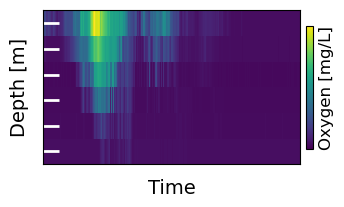

In [89]:
fig, ax = plt.subplots(figsize=(4, 2))

# oxygen and oxygen logger depths
im = ds_do.d_oxygen_conc.plot(cmap='viridis', vmin=0, cbar_kwargs={'shrink': 0.8, 'pad':0.02}, rasterized=True, ax=ax)
im.colorbar.set_ticks([])
im.colorbar.ax.set_ylabel('Oxygen [mg/L]', fontsize=12, labelpad=5)
for d in ds_do.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', bottom=False, labelbottom=False, left=False, labelleft=False)
ax.invert_yaxis()

plt.savefig('../gallery/surf/2026_03_16/minidot.svg', bbox_inches='tight')
plt.show()

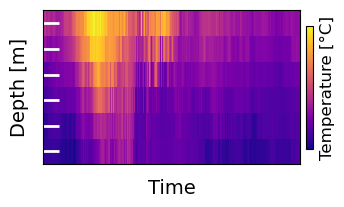

In [90]:
fig, ax = plt.subplots(figsize=(4, 2))

# temperature and thermistor depths
im = ds_temp.temp.plot(cmap='plasma', cbar_kwargs={'shrink': 0.8, 'pad':0.02}, rasterized=True, ax=ax)
im.colorbar.set_ticks([])
im.colorbar.ax.set_ylabel('Temperature [°C]', fontsize=12, labelpad=5)
ax.xaxis.get_offset_text().set_fontsize(12)
for d in ds_temp.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', bottom=False, labelbottom=False, left=False, labelleft=False)
ax.invert_yaxis()

plt.savefig('../gallery/surf/2026_03_16/rbr_temp.svg', bbox_inches='tight')
plt.show()

#### Lake Zug maps

Mooring locations, microstructure locations, water sample locations.

In [97]:
bathy_zug = xr.open_dataset('Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/bathymetry.nc')

# planned locations
locs_zug = pd.DataFrame({
    'name': ["P1", "P2", "P3", "VMPN", "P05'", "P05''", "LZC", "LZW", "LZE", "P7", "P8", "P9", "VMPS", "P10", "P11", "P12", "L1", "L2", "L3"],
    'xsc': [679803, 679803, 679663, 679250, 679322, 679711, 680090, 679884, 680328, 680150, 680223, 680409, 680600, 680814, 681350, 681909, 679322, 679322, 681510],
    'ysc': [224100, 222690, 221650, 220433, 219531, 219097, 218816, 218764, 218866, 218462, 218126, 217437, 216834, 216239, 214957, 213760, 217600, 215450, 216934],
    'mooring': [False, False, False, False, True, False, True, True, True, False, False, True, False, False, False, False, False, False, False],
    'microstructure': [False, False, False, True, False, False, True, True, True, False, False, False, True, False, False, False, False, False, False],
    'water_sample': [False, False, False, True, False, False, True, False, False, False, False, False, True, False, False, False, True, True, True]
})
# VMPS xsc = 680442
locs_zug['xsc'] += int(2e6)
locs_zug['ysc'] += int(1e6)

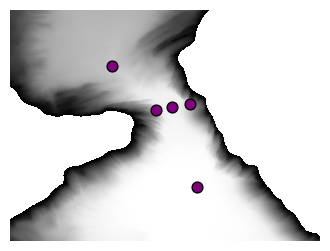

In [98]:
bathy_zug_sel = bathy_zug.sel(xsc=slice(2678000, 2682000), ysc=slice(1216500, 1220500))

fig, ax = plt.subplots(figsize=(4, 3))

im = ax.pcolormesh(bathy_zug_sel['xsc'], bathy_zug_sel['ysc'], bathy_zug_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)

# fieldwork locations
for _, row in locs_zug.iterrows():
    if row['mooring']:
        ax.scatter(row.xsc, row.ysc, s=60, c='purple', edgecolor='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/surf/2026_03_16/zug_moorings.svg', bbox_inches='tight')
plt.show()

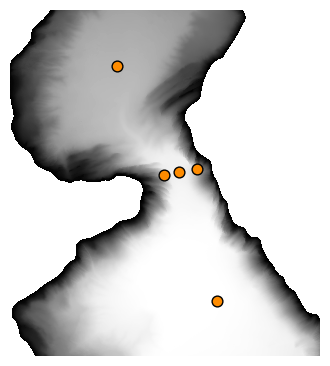

In [102]:
bathy_zug_sel = bathy_zug.sel(xsc=slice(2677800, 2682000), ysc=slice(1216000, 1221300))

fig, ax = plt.subplots(figsize=(4, 4.5))

im = ax.pcolormesh(bathy_zug_sel['xsc'], bathy_zug_sel['ysc'], bathy_zug_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)

# fieldwork locations
for _, row in locs_zug.iterrows():
    if row['microstructure']:
        ax.scatter(row.xsc, row.ysc, s=60, c='darkorange', edgecolor='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/surf/2026_03_16/zug_microstructure.svg', bbox_inches='tight')
plt.show()

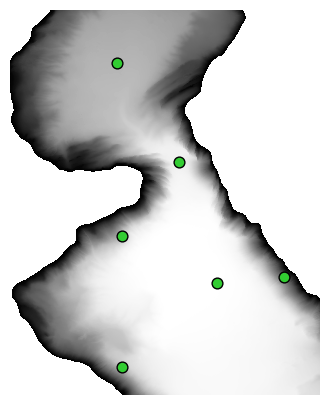

In [103]:
bathy_zug_sel = bathy_zug.sel(xsc=slice(2677800, 2682000), ysc=slice(1215000, 1221300))

fig, ax = plt.subplots(figsize=(4, 5))

im = ax.pcolormesh(bathy_zug_sel['xsc'], bathy_zug_sel['ysc'], bathy_zug_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)

# fieldwork locations
for _, row in locs_zug.iterrows():
    if row['water_sample']:
        ax.scatter(row.xsc, row.ysc, s=60, c='limegreen', edgecolor='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/surf/2026_03_16/zug_watersamples.svg', bbox_inches='tight')
plt.show()

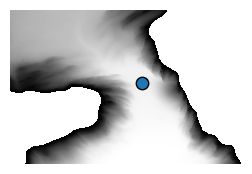

In [99]:
bathy_zug_sel = bathy_zug.sel(xsc=slice(2678500, 2681300), ysc=slice(1217500, 1220000))

fig, ax = plt.subplots(figsize=(3, 2))

im = ax.pcolormesh(bathy_zug_sel['xsc'], bathy_zug_sel['ysc'], bathy_zug_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)

# fieldwork locations
for _, row in locs_zug.iterrows():
    if row['name'] == 'LZC':
        ax.scatter(row.xsc, row.ysc, s=80, c='tab:blue', edgecolor='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/surf/2026_03_16/moorings_a3.svg', bbox_inches='tight')
plt.show()

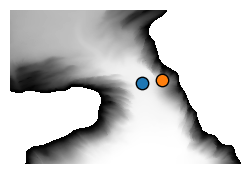

In [100]:
bathy_zug_sel = bathy_zug.sel(xsc=slice(2678500, 2681300), ysc=slice(1217500, 1220000))

fig, ax = plt.subplots(figsize=(3, 2))

im = ax.pcolormesh(bathy_zug_sel['xsc'], bathy_zug_sel['ysc'], bathy_zug_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)

# fieldwork locations
for _, row in locs_zug.iterrows():
    if row['name'] == 'LZC':
        ax.scatter(row.xsc, row.ysc, s=80, c='tab:blue', edgecolor='black')
    elif row['name'] == 'LZE':
        ax.scatter(row.xsc, row.ysc, s=80, c='tab:orange', edgecolor='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/surf/2026_03_16/moorings_a1.svg', bbox_inches='tight')
plt.show()

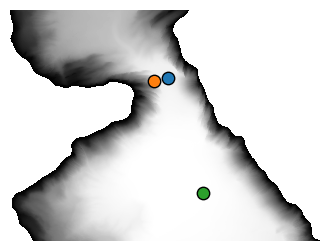

In [101]:
bathy_zug_sel = bathy_zug.sel(xsc=slice(2677800, 2682300), ysc=slice(1216000, 1220000))

fig, ax = plt.subplots(figsize=(4, 3))

im = ax.pcolormesh(bathy_zug_sel['xsc'], bathy_zug_sel['ysc'], bathy_zug_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)

# fieldwork locations
for _, row in locs_zug.iterrows():
    if row['name'] == 'LZC':
        ax.scatter(row.xsc, row.ysc, s=80, c='tab:blue', edgecolor='black')
    elif row['name'] == 'LZW':
        ax.scatter(row.xsc, row.ysc, s=80, c='tab:orange', edgecolor='black')
    elif row['name'] == 'VMPS':
        ax.scatter(row.xsc, row.ysc, s=80, c='tab:green', edgecolor='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/surf/2026_03_16/mctd_a2.svg', bbox_inches='tight')
plt.show()

#### Lake Lucerne maps

Mooring locations, microstructure locations, water sample locations.

In [109]:
locs_lucerne

,name,xsc,ysc,mooring,microstructure,water_sample,total_depth
0,P1,2689164,1195729,False,False,False,97.7263
1,P2,2688831,1197528,False,False,False,170.9585
2,P3,2688597,1200315,False,True,True,195.3210
3,P4,2688597,1202685,True,False,False,198.0686
4,P5,2688620,1204100,False,False,False,189.3597
5,P6,2688460,1204750,False,False,False,162.3014
6,P7,2687945,1205025,True,True,True,106.8098
7,P7S,2687870,1204800,True,True,False,118.7761
8,P7N,2688020,1205250,True,True,False,71.4485
9,P8,2687442,1205150,False,False,False,84.1308


In [117]:
bathy_lucerne = xr.open_dataset('Q:/Messdaten/Aphys_Hypothesis_data/Lucerne/bathymetry.nc')
bathy_lucerne = bathy_lucerne.sel(xsc=slice(2674000, None), ysc=slice(None, 1206500))    # Gersauersee and Urnersee

# planned locations
locs_lucerne = pd.DataFrame({
    'name': ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P7S", "P7N", "P8", "P9", "P10", "P11", "P12", "P13", "P14", "L1", "L2", "P0"],
    'xsc': [689164, 688831, 688597, 688597, 688620, 688460, 687945, 687870, 688020, 687442, 686760, 685900, 684542, 683150, 681157, 678966, 687450, 689700, 678281],
    'ysc': [195729, 197528, 200315, 202685, 204100, 204750, 205025, 204800, 205250, 205150, 205150, 204700, 204000, 203740, 203590, 203863, 200315, 200315, 205530],
    'mooring': [False, False, False, True, False, False, True, True, True, False, False, True, True, False, False, False, False, False, False],
    'microstructure': [False, False, True, False, False, False, True, True, True, False, False, True, True, False, True, False, False, False, False],
    'water_sample': [False, False, True, False, False, False, True, False, False, False, False, True, False, False, True, False, True, True, False]
})

locs_lucerne['xsc'] += int(2e6)
locs_lucerne['ysc'] += int(1e6)
locs_lucerne['total_depth'] = [bathy_lucerne.sel(xsc=row.xsc, ysc=row.ysc).depth.item() for _, row in locs_lucerne.iterrows()]

# distance along transect from Gersaursee to Urnersee
locs_lucerne_transect = locs_lucerne[~locs_lucerne['name'].isin(['P7S', 'P7N', 'L1', 'L2'])]
x = np.diff(locs_lucerne_transect.xsc[::-1])    # reverse order
y = np.diff(locs_lucerne_transect.ysc[::-1])
dist = np.sqrt(x**2 + y**2)
dist_transect = np.concatenate([np.array([0]), np.cumsum(dist)])
locs_lucerne_transect['dist_transect'] = dist_transect[::-1]    # reverse order back

C:\Users\herremha\AppData\Local\Temp\ipykernel_12616\2451240301.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locs_lucerne_transect['dist_transect'] = dist_transect[::-1]    # reverse order back


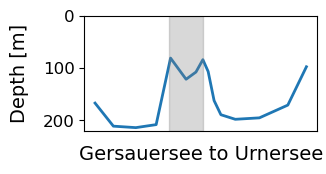

In [119]:
fig, ax = plt.subplots(figsize=(3, 1.5))

sns.lineplot(locs_lucerne_transect, x='dist_transect', y='total_depth', color='tab:blue', marker=None, lw=2, zorder=1, ax=ax)
ax.axvspan(7300, 10600, color='gray', alpha=0.3)


ax.set_xlabel('Gersauersee to Urnersee', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_xticks([])
ax.tick_params(axis='both', labelsize=12)

ax.set_ylim(0, None)
ax.invert_yaxis()
#ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../gallery/surf/2026_03_16/lucerne_GU_bathy.svg', bbox_inches='tight')
plt.show()

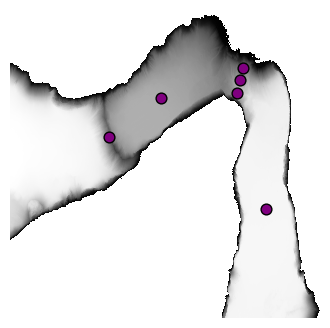

In [131]:
bathy_lucerne_sel = bathy_lucerne.sel(xsc=slice(2682000, 2690000), ysc=slice(1200700, 1206300))

fig, ax = plt.subplots(figsize=(4, 4))

im = ax.pcolormesh(bathy_lucerne_sel['xsc'], bathy_lucerne_sel['ysc'], bathy_lucerne_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)

# fieldwork locations
for _, row in locs_lucerne.iterrows():
    if row['mooring']:
        ax.scatter(row.xsc, row.ysc, s=60, c='purple', edgecolor='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/surf/2026_03_16/lucerne_moorings.svg', bbox_inches='tight')
plt.show()

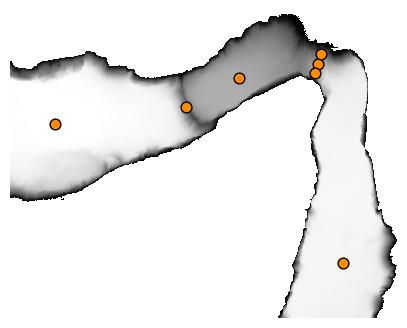

In [128]:
bathy_lucerne_sel = bathy_lucerne.sel(xsc=slice(2680000, 2690000), ysc=slice(1199000, 1206300))

fig, ax = plt.subplots(figsize=(5, 4))

im = ax.pcolormesh(bathy_lucerne_sel['xsc'], bathy_lucerne_sel['ysc'], bathy_lucerne_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)

# fieldwork locations
for _, row in locs_lucerne.iterrows():
    if row['microstructure']:
        ax.scatter(row.xsc, row.ysc, s=60, c='darkorange', edgecolor='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/surf/2026_03_16/lucerne_microstructure.svg', bbox_inches='tight')
plt.show()

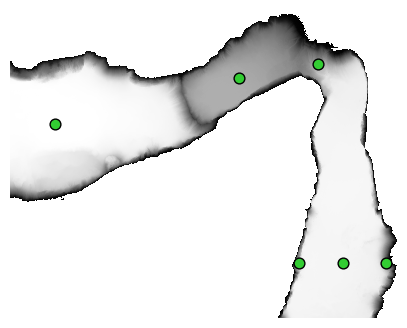

In [132]:
bathy_lucerne_sel = bathy_lucerne.sel(xsc=slice(2680000, 2690000), ysc=slice(1199000, 1206300))

fig, ax = plt.subplots(figsize=(5, 4))

im = ax.pcolormesh(bathy_lucerne_sel['xsc'], bathy_lucerne_sel['ysc'], bathy_lucerne_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)

# fieldwork locations
for _, row in locs_lucerne.iterrows():
    if row['water_sample']:
        ax.scatter(row.xsc, row.ysc, s=60, c='limegreen', edgecolor='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/surf/2026_03_16/lucerne_watersamples.svg', bbox_inches='tight')
plt.show()